In [3]:
import polars as pl
import xgboost as xgb
import pandas as pd
import numpy as np
import gc
from sklearn.metrics import average_precision_score, classification_report, precision_score, recall_score, f1_score

# 1. 파일 경로 설정
v2_path = "/home/tracerofjageum/aml_features_v2_integrated_final.parquet"
graph_path = "./graph_features_final_v3.parquet"

print("🚀 [V3 진검승부] V2 로직 계승 + 계좌 단위 샘플링 기반 비교 실험 시작...")

try:
    # 2. 데이터 병합 (V2 통계 + V3 그래프)
    df_v2 = pl.read_parquet(v2_path)
    df_graph = pl.read_parquet(graph_path)

    # account_id 기준으로 Join
    df_v2 = df_v2.with_columns(pl.col("account_id").cast(pl.String))
    df_graph = df_graph.with_columns(pl.col("account_id").cast(pl.String))
    df_all = df_v2.join(df_graph, on="account_id", how="left")

    # 그래프 피처 결측치 처리 (신규 노드는 0으로)
    graph_cols = [c for c in df_graph.columns if c != "account_id"]
    df_all = df_all.with_columns([pl.col(c).fill_null(0) for c in graph_cols])
    
    del df_v2, df_graph
    gc.collect()

    # 3. 계좌(Node) 단위 층화 샘플링 (20%) - 자금 흐름 히스토리 보존
    print("🔍 계좌 단위 층화 추출 중 (20% 샘플링)...")
    acc_labels = df_all.group_by("account_id").agg(pl.col("is_laundering").max().alias("is_fraud_acc"))
    
    fraud_accs = acc_labels.filter(pl.col("is_fraud_acc") == 1).sample(fraction=0.2, seed=42)
    normal_accs = acc_labels.filter(pl.col("is_fraud_acc") == 0).sample(fraction=0.2, seed=42)
    selected_accs = pl.concat([fraud_accs, normal_accs]).select("account_id")

    # 선택된 계좌의 모든 거래 내역 확보
    df_sample = df_all.join(selected_accs, on="account_id", how="inner").sort("time_group")
    
    del df_all, acc_labels, fraud_accs, normal_accs, selected_accs
    gc.collect()

    # 4. 데이터 분할 (V2와 동일한 6:2:2 시간 기반 분할)
    total_len = len(df_sample)
    train_end = int(total_len * 0.6)
    val_end = int(total_len * 0.8)

    # 피처 선택 (메타데이터 및 정답 데이터 제외)
    exclude_cols = ["account_id", "time_group", "is_laundering", "mode_format", "currency_mode", 
                    "Timestamp", "timestamp", "is_fraud_node_train", "community_id"]
    features = [c for c in df_sample.columns if c not in exclude_cols]
    target = "is_laundering"

    # Pandas/DMatrix 변환
    X_train = df_sample[:train_end].select(features).to_pandas()
    y_train = df_sample[:train_end].select(target).to_pandas()
    X_val = df_sample[train_end:val_end].select(features).to_pandas()
    y_val = df_sample[train_end:val_end].select(target).to_pandas()
    X_test_pl = df_sample[val_end:]
    X_test = X_test_pl.select(features).to_pandas()
    y_test = X_test_pl.select(target).to_pandas()

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # =========================================================================
    # 🥊 [Model 1] 튜닝 전 (Basic) - V1 스타일
    # =========================================================================
    print("\n📦 [Model 1] 튜닝 전 (Basic) 학습 중...")
    params_basic = {
        'objective': 'binary:logistic', 'eval_metric': 'aucpr',
        'learning_rate': 0.3, 'scale_pos_weight': 1, 'tree_method': 'hist', 'random_state': 42
    }
    model_basic = xgb.train(params_basic, dtrain, num_boost_round=100)
    preds_basic = model_basic.predict(dtest)

    # =========================================================================
    # 🥊 [Model 2] 튜닝 후 (Tuned) - V2 고도화 스타일
    # =========================================================================
    print("✨ [Model 2] 튜닝 후 (Tuned) 학습 중...")
    params_tuned = {
        'objective': 'binary:logistic', 'eval_metric': 'aucpr',
        'max_depth': 5, 'learning_rate': 0.05, 'scale_pos_weight': 100, # V2 핵심 파라미터
        'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'random_state': 42
    }
    model_tuned = xgb.train(params_tuned, dtrain, num_boost_round=500, 
                            evals=[(dval, 'val')], early_stopping_rounds=20, verbose_eval=False)
    preds_tuned = model_tuned.predict(dtest)

    # =========================================================================
    # 📊 [통합 평가 리포트]
    # =========================================================================
    def evaluate_performance(y_true, prob, df_test_pl, name, thr=0.7):
        y_true_vals = y_true.values.flatten()
        y_pred = (prob > thr).astype(int)
        
        # 기본 지표
        auprc = average_precision_score(y_true_vals, prob)
        prec = precision_score(y_true_vals, y_pred, zero_division=0)
        rec = recall_score(y_true_vals, y_pred, zero_division=0)
        f1 = f1_score(y_true_vals, y_pred, zero_division=0)
        
        # Top-K 탐지 성능
        res_df = pd.DataFrame({'prob': prob, 'actual': y_true_vals})
        top_k_hits = {k: int(res_df.sort_values('prob', ascending=False).head(k)['actual'].sum()) for k in [100, 500, 1000, 5000]}
        
        # 일자별 분석 (Prec@100)
        res_df['date'] = pd.to_datetime(df_test_pl['time_group'].to_pandas()).dt.date
        daily_hits = []
        for d, g in res_df.groupby('date'):
            daily_hits.append(g.sort_values('prob', ascending=False).head(100)['actual'].sum())
        avg_daily = np.mean(daily_hits)
        
        return {'AUPRC': auprc, 'Prec': prec, 'Rec': rec, 'F1': f1, 'Top-K': top_k_hits, 'Daily': avg_daily}

    res_b = evaluate_performance(y_test, preds_basic, X_test_pl, "Basic")
    res_t = evaluate_performance(y_test, preds_tuned, X_test_pl, "Tuned")

    # 결과 테이블 출력
    print("\n" + "="*70)
    print(f"{'Metric':<25} | {'Before (Basic)':<15} | {'After (Tuned)':<15}")
    print("-" * 70)
    metrics = [('AUPRC', 'AUPRC'), ('Precision (0.7)', 'Prec'), ('Recall (0.7)', 'Rec'), ('F1-Score (0.7)', 'F1'), ('Avg Daily Hits@100', 'Daily')]
    for label, key in metrics:
        print(f"{label:<25} | {res_b[key]:.4f}          | {res_t[key]:.4f}")
    
    print("-" * 70)
    for k in [100, 500, 1000, 5000]:
        print(f"Top-{k:<4} Hits           | {res_b['Top-K'][k]:<15} | {res_t['Top-K'][k]:<15}")
    print("="*70)

except Exception as e:
    import traceback
    print(f"❌ 에러 발생: {e}")
    traceback.print_exc()

🚀 [V3 진검승부] V2 로직 계승 + 계좌 단위 샘플링 기반 비교 실험 시작...
🔍 계좌 단위 층화 추출 중 (20% 샘플링)...

📦 [Model 1] 튜닝 전 (Basic) 학습 중...
✨ [Model 2] 튜닝 후 (Tuned) 학습 중...

Metric                    | Before (Basic)  | After (Tuned)  
----------------------------------------------------------------------
AUPRC                     | 0.2562          | 0.3285
Precision (0.7)           | 0.6590          | 0.1775
Recall (0.7)              | 0.2015          | 0.5140
F1-Score (0.7)            | 0.3086          | 0.2639
Avg Daily Hits@100        | 61.2143          | 66.6429
----------------------------------------------------------------------
Top-100  Hits           | 67              | 96             
Top-500  Hits           | 340             | 462            
Top-1000 Hits           | 670             | 785            
Top-5000 Hits           | 1539            | 1597           


In [1]:
import polars as pl
import xgboost as xgb
import pandas as pd
import numpy as np
import gc
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score

# 1. 파일 경로 설정
v2_path = "/home/tracerofjageum/aml_features_v2_integrated_final.parquet"
graph_path = "./graph_features_final_v3.parquet"

print("🚀 [전체 데이터 학습] 2,800만 건 V3 모델 진검승부 시작...")

try:
    # 2. 데이터 병합 (메모리 절약을 위해 Polars 사용)
    print("📂 데이터 로드 및 병합 중...")
    df_v2 = pl.read_parquet(v2_path)
    df_graph = pl.read_parquet(graph_path)

    # account_id 기준으로 Join
    df_v2 = df_v2.with_columns(pl.col("account_id").cast(pl.String))
    df_graph = df_graph.with_columns(pl.col("account_id").cast(pl.String))
    df_all = df_v2.join(df_graph, on="account_id", how="left")

    # 메모리 해제
    del df_v2, df_graph
    gc.collect()

    # 3. 전처리 및 교차 피처 생성 (V2 로직 계승)
    print("⚡ V2 전처리 로직 및 그래프 교차 피처 적용 중...")
    graph_cols = ["pagerank", "in_degree", "out_degree", "betweenness_centrality", "degree_ratio", "community_fraud_ratio"]
    
    # 결측치 0 채우기 & 교차 피처
    df_all = df_all.with_columns([pl.col(c).fill_null(0).cast(pl.Float32) for c in graph_cols])
    df_all = df_all.with_columns([
        (pl.col("pagerank") * pl.col("sum_1h")).alias("pagerank_weighted_vol"),
        (pl.col("community_fraud_ratio") * pl.col("cnt_1h")).alias("community_risk_signal")
    ])

    # 4. 시간 기반 6:2:2 분할 준비
    df_all = df_all.sort("time_group")
    total_len = len(df_all)
    train_end = int(total_len * 0.6)
    val_end = int(total_len * 0.8)

    # 피처 정의
    exclude_cols = ["account_id", "time_group", "is_laundering", "mode_format", "currency_mode", 
                    "Timestamp", "timestamp", "is_fraud_node_train", "community_id"]
    features = [c for c in df_all.columns if c not in exclude_cols]
    target = "is_laundering"
    
    print(f"📊 학습 피처 총 {len(features)}개 확보")

    # 5. 메모리 효율적 DMatrix 생성 (순차적 변환)
    print("🚀 데이터셋 변환 중 (Train -> Val -> Test)...")
    
    # Train
    X_train = df_all[:train_end].select(features).to_pandas().astype('float32')
    y_train = df_all[:train_end].select(target).to_pandas()
    dtrain = xgb.DMatrix(X_train, label=y_train)
    del X_train, y_train
    gc.collect()

    # Val
    X_val = df_all[train_end:val_end].select(features).to_pandas().astype('float32')
    y_val = df_all[train_end:val_end].select(target).to_pandas()
    dval = xgb.DMatrix(X_val, label=y_val)
    del X_val, y_val
    gc.collect()

    # Test (날짜 정보 보존)
    df_test_pl = df_all[val_end:]
    X_test = df_test_pl.select(features).to_pandas().astype('float32')
    y_test = df_test_pl.select(target).to_pandas()
    dtest = xgb.DMatrix(X_test, label=y_test)
    
    # 원본 df_all 삭제하여 메모리 최대 확보
    del df_all
    gc.collect()

    # 6. 모델 학습
    # Model 1: Basic (V1 Baseline 스타일)
    print("\n📦 [Model 1] 튜닝 전 (Basic) 학습 시작...")
    params_basic = {
        'objective': 'binary:logistic', 'eval_metric': 'aucpr',
        'learning_rate': 0.3, 'scale_pos_weight': 1, 'tree_method': 'hist', 'random_state': 42
    }
    model_basic = xgb.train(params_basic, dtrain, num_boost_round=100)
    preds_basic = model_basic.predict(dtest)

    # Model 2: Tuned (V2 Optimized 스타일)
    print("✨ [Model 2] 튜닝 후 (Tuned) 학습 시작...")
    params_tuned = {
        'objective': 'binary:logistic', 'eval_metric': 'aucpr',
        'max_depth': 5, 'learning_rate': 0.05, 'scale_pos_weight': 100, # 핵심
        'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'random_state': 42
    }
    model_tuned = xgb.train(params_tuned, dtrain, num_boost_round=500, 
                            evals=[(dval, 'val')], early_stopping_rounds=20, verbose_eval=False)
    preds_tuned = model_tuned.predict(dtest)

    # 7. 통합 평가 (Top-K & Daily 분석)
    def evaluate_full(y_true, prob, df_test_pl, name, thr=0.7):
        y_true_vals = y_true.values.flatten()
        y_pred = (prob > thr).astype(int)
        
        # 기본 지표
        auprc = average_precision_score(y_true_vals, prob)
        prec = precision_score(y_true_vals, y_pred, zero_division=0)
        rec = recall_score(y_true_vals, y_pred, zero_division=0)
        
        # Top-K (계좌 단위 Distinct 가이드라인 반영 시도 가능하나 일단 행 단위로 비교)
        res_df = pd.DataFrame({'prob': prob, 'actual': y_true_vals})
        top_k = {k: int(res_df.sort_values('prob', ascending=False).head(k)['actual'].sum()) for k in [100, 500, 1000, 5000]}
        
        # 일별 분석
        res_df['date'] = pd.to_datetime(df_test_pl['time_group'].to_pandas()).dt.date
        daily = [g.sort_values('prob', ascending=False).head(100)['actual'].sum() for d, g in res_df.groupby('date')]
        
        return {'AUPRC': auprc, 'Prec': prec, 'Rec': rec, 'Top-K': top_k, 'Daily': np.mean(daily)}

    res_b = evaluate_full(y_test, preds_basic, df_test_pl, "Basic")
    res_t = evaluate_full(y_test, preds_tuned, df_test_pl, "Tuned")

    # 최종 결과 출력
    print("\n" + "="*70)
    print(f"🏆 [V3 전체 데이터 결과] 튜닝 전 vs 후 비교")
    print("="*70)
    print(f"{'Metric':<25} | {'Before (Basic)':<15} | {'After (Tuned)':<15}")
    print("-" * 70)
    print(f"{'AUPRC':<25} | {res_b['AUPRC']:.4f}          | {res_t['AUPRC']:.4f}")
    print(f"{'Precision (0.7)':<25} | {res_b['Prec']:.4f}          | {res_t['Prec']:.4f}")
    print(f"{'Recall (0.7)':<25} | {res_b['Rec']:.4f}          | {res_t['Rec']:.4f}")
    print(f"{'Avg Daily Hits@100':<25} | {res_b['Daily']:.2f}           | {res_t['Daily']:.2f}")
    print("-" * 70)
    for k in [100, 500, 1000, 5000]:
        print(f"Top-{k:<4} Hits           | {res_b['Top-K'][k]:<15} | {res_t['Top-K'][k]:<15}")
    print("="*70)

except Exception as e:
    import traceback
    print(f"❌ 에러: {e}")
    traceback.print_exc()

🚀 [전체 데이터 학습] 2,800만 건 V3 모델 진검승부 시작...
📂 데이터 로드 및 병합 중...
⚡ V2 전처리 로직 및 그래프 교차 피처 적용 중...
📊 학습 피처 총 46개 확보
🚀 데이터셋 변환 중 (Train -> Val -> Test)...

📦 [Model 1] 튜닝 전 (Basic) 학습 시작...
✨ [Model 2] 튜닝 후 (Tuned) 학습 시작...


KeyboardInterrupt: 

In [2]:
import polars as pl
import xgboost as xgb
import pandas as pd
import numpy as np
import gc
from sklearn.metrics import average_precision_score, classification_report, precision_score, recall_score
import warnings

warnings.filterwarnings('ignore')

# 1. 경로 설정
v2_path = "/home/tracerofjageum/aml_features_v2_integrated_final.parquet"
graph_path = "./graph_features_final_v3.parquet"

print("🚀 [전체 데이터] V3 모델 학습 및 V2 로직 기반 평가 시작...")

try:
    # 2. 데이터 병합 (Polars 사용 - 메모리 최적화)
    print("📂 데이터 로딩 및 병합 중...")
    df_v2 = pl.read_parquet(v2_path)
    df_graph = pl.read_parquet(graph_path)

    # account_id 기준 Join (V2 로직)
    df_v2 = df_v2.with_columns(pl.col("account_id").cast(pl.String))
    df_graph = df_graph.with_columns(pl.col("account_id").cast(pl.String))
    df = df_v2.join(df_graph, on="account_id", how="left")

    del df_v2, df_graph; gc.collect()

    # 3. [V2 전처리 계승] 결측치 처리 및 교차 피처 생성
    print("⚡ V2 전처리 로직 적용 중...")
    graph_cols = ["pagerank", "in_degree", "out_degree", "betweenness_centrality", "degree_ratio", "community_fraud_ratio"]
    df = df.with_columns([pl.col(c).fill_null(0).cast(pl.Float32) for c in graph_cols if c in df.columns])
    
    # 그래프-통계 교차 피처
    df = df.with_columns([
        (pl.col("pagerank") * pl.col("sum_1h")).alias("pagerank_weighted_vol"),
        (pl.col("community_fraud_ratio") * pl.col("cnt_1h")).alias("community_risk_signal")
    ])

    # 4. [V2 분할 로직] 시간 순서 6:2:2 분할
    print("✂️ 시간 기반 데이터 분할 중 (6:2:2)...")
    df = df.sort("time_group")
    total_len = len(df)
    train_end = int(total_len * 0.6)
    val_end = int(total_len * 0.8)

    # 피처 선택 (V2 exclude_cols 준수)
    exclude_cols = ["account_id", "time_group", "is_laundering", "mode_format", "currency_mode", 
                    "Timestamp", "timestamp", "is_fraud_node_train", "community_id"]
    features = [c for c in df.columns if c not in exclude_cols]
    target = "is_laundering"
    
    print(f"📊 최종 학습 피처 수: {len(features)}개")

    # 5. [메모리 최적화] DMatrix 순차 변환
    print("🚀 DMatrix 변환 중 (메모리 절약 모드)...")
    
    # Train
    X_train = df[:train_end].select(features).to_pandas().astype('float32')
    y_train = df[:train_end].select(target).to_pandas()
    dtrain = xgb.DMatrix(X_train, label=y_train); del X_train, y_train; gc.collect()

    # Val
    X_val = df[train_end:val_end].select(features).to_pandas().astype('float32')
    y_val = df[train_end:val_end].select(target).to_pandas()
    dval = xgb.DMatrix(X_val, label=y_val); del X_val, y_val; gc.collect()

    # Test
    test_pl = df[val_end:]
    X_test = test_pl.select(features).to_pandas().astype('float32')
    y_test = test_pl.select(target).to_pandas()
    dtest = xgb.DMatrix(X_test, label=y_test); del df; gc.collect()

    # -------------------------------------------------------------------------
    # 🥊 [Model 1] 튜닝 전 (Basic - V1 스타일)
    # -------------------------------------------------------------------------
    print("\n📦 [Model 1] 튜닝 전 (Basic) 학습 시작...")
    params_basic = {
        'objective': 'binary:logistic', 'eval_metric': 'aucpr',
        'learning_rate': 0.3, 'scale_pos_weight': 1, 'tree_method': 'hist', 'random_state': 42
    }
    model_basic = xgb.train(params_basic, dtrain, num_boost_round=100)
    preds_basic = model_basic.predict(dtest)

    # -------------------------------------------------------------------------
    # 🥊 [Model 2] 튜닝 후 (Tuned - V2 고도화 스타일)
    # -------------------------------------------------------------------------
    print("✨ [Model 2] 튜닝 후 (Tuned) 학습 시작...")
    params_tuned = {
        'objective': 'binary:logistic', 'eval_metric': 'aucpr',
        'max_depth': 5, 'learning_rate': 0.05, 
        'scale_pos_weight': 100, # V2 핵심 튜닝값
        'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'random_state': 42
    }
    model_tuned = xgb.train(params_tuned, dtrain, num_boost_round=1000, 
                            evals=[(dval, 'val')], early_stopping_rounds=20, verbose_eval=100)
    preds_tuned = model_tuned.predict(dtest)

    # -------------------------------------------------------------------------
    # 📊 [V2 평가 로직 계승] analyze_top_k 및 일별 분석
    # -------------------------------------------------------------------------
    def analyze_v3_results(df_test_pl, probs, labels, name, ks=[100, 500, 1000, 5000]):
        y_true = labels.values.flatten()
        results = pd.DataFrame({
            'date': df_test_pl['time_group'].dt.date().to_pandas(), 
            'prob': probs, 
            'actual': y_true
        })
        
        print(f"\n📢 [{name} 모델 평가 리포트]")
        print(f"✅ AUPRC: {average_precision_score(y_true, probs):.4f}")
        
        # 1. 전체 Top-K (행 단위)
        print(f"--- [전체 Top-K 탐지 성능] ---")
        sorted_df = results.sort_values(by='prob', ascending=False).reset_index(drop=True)
        for k in ks:
            hits = sorted_df.head(k)['actual'].sum()
            print(f"Top {k:<5} | 실제 범인: {int(hits):<6} | 정밀도: {hits/k:.2%}")
        
        # 2. 일자별 Top-100 탐지 성능
        print(f"\n--- [일자별 Top-100 탐지 성능] ---")
        daily_report = []
        for date, group in results.groupby('date'):
            group = group.sort_values(by='prob', ascending=False)
            hits = group.head(100)['actual'].sum()
            daily_report.append({'Date': date, 'Hits@100': int(hits), 'Prec@100': f"{hits/100:.1%}"})
        print(pd.DataFrame(daily_report).to_string(index=False))

    analyze_v3_results(test_pl, preds_basic, y_test, "V3 Basic")
    analyze_v3_results(test_pl, preds_tuned, y_test, "V3 Tuned")

except Exception as e:
    import traceback
    print(f"❌ 에러: {e}")
    traceback.print_exc()

🚀 [전체 데이터] V3 모델 학습 및 V2 로직 기반 평가 시작...
📂 데이터 로딩 및 병합 중...
⚡ V2 전처리 로직 적용 중...
✂️ 시간 기반 데이터 분할 중 (6:2:2)...
📊 최종 학습 피처 수: 46개
🚀 DMatrix 변환 중 (메모리 절약 모드)...

📦 [Model 1] 튜닝 전 (Basic) 학습 시작...
✨ [Model 2] 튜닝 후 (Tuned) 학습 시작...
[0]	val-aucpr:0.09730
[100]	val-aucpr:0.27181
[200]	val-aucpr:0.30779
[300]	val-aucpr:0.31911
[400]	val-aucpr:0.32926
[478]	val-aucpr:0.33139

📢 [V3 Basic 모델 평가 리포트]
✅ AUPRC: 0.1721
--- [전체 Top-K 탐지 성능] ---
Top 100   | 실제 범인: 61     | 정밀도: 61.00%
Top 500   | 실제 범인: 263    | 정밀도: 52.60%
Top 1000  | 실제 범인: 544    | 정밀도: 54.40%
Top 5000  | 실제 범인: 3013   | 정밀도: 60.26%

--- [일자별 Top-100 탐지 성능] ---
      Date  Hits@100 Prec@100
2022-09-14        54    54.0%
2022-09-15        49    49.0%
2022-09-16        24    24.0%
2022-09-17       100   100.0%
2022-09-18       100   100.0%
2022-09-19       100   100.0%
2022-09-20       100   100.0%
2022-09-21       100   100.0%
2022-09-22       100   100.0%
2022-09-23       100   100.0%
2022-09-24       100   100.0%
2022-09-25       10


🏆 [V3 Basic (Before Tuning) 모델 상세 리포트 (Threshold=0.7)]
              precision    recall  f1-score   support

       False     0.9971    0.9993    0.9982   5730722
        True     0.5055    0.1996    0.2862     20539

    accuracy                         0.9964   5751261
   macro avg     0.7513    0.5995    0.6422   5751261
weighted avg     0.9954    0.9964    0.9957   5751261

📌 Final Average Precision (AUPRC): 0.1721

🏆 [V3 Tuned (After Tuning) 모델 상세 리포트 (Threshold=0.7)]
              precision    recall  f1-score   support

       False     0.9983    0.9914    0.9949   5730722
        True     0.1843    0.5413    0.2750     20539

    accuracy                         0.9898   5751261
   macro avg     0.5913    0.7663    0.6349   5751261
weighted avg     0.9954    0.9898    0.9923   5751261

📌 Final Average Precision (AUPRC): 0.3518

🔥 [고도화 모델 피처 중요도 - Gain 기준 Top 15]
 1. ratio_cross_border             |     42250.77 🕸️ [Graph]
 2. cnt_risk_format                |     40256.73 
 3.

<Figure size 1000x800 with 0 Axes>

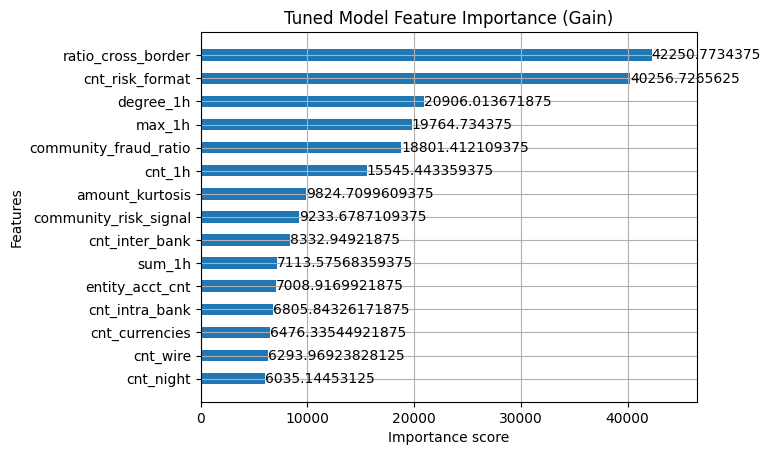

In [7]:
from sklearn.metrics import classification_report, average_precision_score
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. 성능 지표 통합 추출 함수 정의
# -------------------------------------------------------------------------
def get_detailed_report(model, dmatrix, y_true, name, threshold=0.7):
    preds = model.predict(dmatrix)
    preds_binary = (preds > threshold).astype(int)
    
    # (1) Classification Report (Precision, Recall, F1, Accuracy 등)
    report = classification_report(y_true, preds_binary, digits=4)
    
    # (2) AUPRC
    auprc = average_precision_score(y_true, preds)
    
    print(f"\n" + "="*60)
    print(f"🏆 [{name} 모델 상세 리포트 (Threshold={threshold})]")
    print("="*60)
    print(report)
    print(f"📌 Final Average Precision (AUPRC): {auprc:.4f}")
    return preds # 나중에 중요도 분석 등을 위해 반환

# -------------------------------------------------------------------------
# 2. 튜닝 전(Basic) vs 튜닝 후(Tuned) 상세 리포트 출력
# -------------------------------------------------------------------------
# y_test는 이전 코드에서 준비된 정답 레이블입니다.
y_test_vals = y_test.values.flatten()

# Model 1 (Basic) 리포트
get_detailed_report(model_basic, dtest, y_test_vals, "V3 Basic (Before Tuning)")

# Model 2 (Tuned) 리포트
get_detailed_report(model_tuned, dtest, y_test_vals, "V3 Tuned (After Tuning)")


# -------------------------------------------------------------------------
# 3. 고도화(Tuned) 모델 피처 중요도 (Top 15 - Gain 기준) 추출
# -------------------------------------------------------------------------
print("\n" + "="*60)
print("🔥 [고도화 모델 피처 중요도 - Gain 기준 Top 15]")
print("="*60)

# Gain 방식: 해당 피처가 노드를 분할할 때 얻은 평균 정보 이득(성능 기여도)
importance_gain = model_tuned.get_score(importance_type='gain')

# 정렬 및 상위 15개 추출
sorted_gain = sorted(importance_gain.items(), key=lambda x: x[1], reverse=True)[:15]

# 데이터프레임 변환 및 출력
importance_df = pd.DataFrame(sorted_gain, columns=['Feature', 'Gain_Score'])

for i, row in importance_df.iterrows():
    # 그래프 피처 여부 표시 (시각적 구분)
    is_graph = "🕸️ [Graph]" if any(k in row['Feature'].lower() for k in ['pagerank', 'degree', 'community', 'centrality', 'ratio', 'signal']) else ""
    print(f"{i+1:2d}. {row['Feature']:<30} | {row['Gain_Score']:>12.2f} {is_graph}")

# -------------------------------------------------------------------------
# 4. 시각화 (선택 사항)
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 8))
xgb.plot_importance(model_tuned, max_num_features=15, importance_type='gain', height=0.5)
plt.title("Tuned Model Feature Importance (Gain)")
plt.show()

In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import average_precision_score

# 1. 테스트 데이터와 예측값 준비
results = pd.DataFrame({
    'account_id': df_test_pl['account_id'].to_list(),
    'is_laundering': y_test.values.flatten(),
    'prob_v3': preds_tuned 
})

# 2. '신규 계좌' 정의
is_new_acc = (df_test_pl['pagerank'] == 0).to_numpy()

# 3. 그룹별 데이터 분리
old_subset = results[~is_new_acc]
new_subset = results[is_new_acc]

print(f"📊 [검증 결과] 기존 계좌 vs 신규 계좌 데이터 분포")
print("-" * 50)
print(f"1. 기존 계좌(Graph 있음) 수: {len(old_subset):,}건 (사기 건수: {old_subset['is_laundering'].sum()}건)")
print(f"2. 신규 계좌(Graph 없음) 수: {len(new_subset):,}건 (사기 건수: {new_subset['is_laundering'].sum()}건)")
print("-" * 50)

# 4. 안전하게 AUPRC 계산 (데이터가 있고 사기 건수가 1개 이상일 때만 실행)
def safe_auprc(subset, name):
    if len(subset) == 0:
        return f"{name}: 데이터가 없습니다."
    if subset['is_laundering'].sum() == 0:
        return f"{name}: 데이터 내에 사기(1) 라벨이 없어 AUPRC 계산이 불가능합니다."
    
    score = average_precision_score(subset['is_laundering'], subset['prob_v3'])
    return f"{name} AUPRC: {score:.4f}"

print(safe_auprc(old_subset, "기존 계좌"))
print(safe_auprc(new_subset, "신규 계좌"))

📊 [검증 결과] 기존 계좌 vs 신규 계좌 데이터 분포
--------------------------------------------------
1. 기존 계좌(Graph 있음) 수: 5,751,261건 (사기 건수: 20539건)
2. 신규 계좌(Graph 없음) 수: 0건 (사기 건수: 0건)
--------------------------------------------------
기존 계좌 AUPRC: 0.3518
신규 계좌: 데이터가 없습니다.


# 그래프피처에 누락된게있어서 추가하고 다시 돌려보기로함

In [1]:
import polars as pl
import xgboost as xgb
import pandas as pd
import numpy as np
import gc
from sklearn.metrics import classification_report, average_precision_score
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# 1. 데이터 로드 및 병합 (V2 행동 + V3 그래프)
# -----------------------------------------------------------------------------
v2_path = "/home/tracerofjageum/aml_features_v2_integrated_final.parquet"
graph_path = "./graph_features_v3_fixed_no_leakage.parquet"

print("📂 데이터 로드 및 통합 중...")
df_v2 = pl.read_parquet(v2_path)
df_graph = pl.read_parquet(graph_path)

# ID 타입 맞춤 및 병합
df_v2 = df_v2.with_columns(pl.col("account_id").cast(pl.String))
df_graph = df_graph.with_columns(pl.col("account_id").cast(pl.String))
df_all = df_v2.join(df_graph, on="account_id", how="left")

del df_v2, df_graph; gc.collect()

# -----------------------------------------------------------------------------
# 2. 전처리 및 누수 차단 (V2와 1:1 대응)
# -----------------------------------------------------------------------------
# 그래프 피처 결측치 처리
graph_cols = ["pagerank", "in_degree", "out_degree", "clustering_coefficient", 
              "betweenness_centrality", "degree_ratio", "aml_suspicion_score", "community_fraud_ratio"]
df_all = df_all.with_columns([pl.col(c).fill_null(0).cast(pl.Float32) for c in graph_cols])

# 시간 기반 정렬 및 분할 (6:2:2)
df_all = df_all.sort("time_group")
total_len = len(df_all)
train_end = int(total_len * 0.6)
val_end = int(total_len * 0.8)

# 제외 컬럼 설정 (Timestamp 제외하여 누수 원천 차단)
exclude_cols = ["account_id", "time_group", "is_laundering", "mode_format", 
                "currency_mode", "Timestamp", "timestamp", "is_fraud_node_train", "community_id"]
features = [c for c in df_all.columns if c not in exclude_cols]
target = "is_laundering"

print(f"✅ 학습 준비 완료 (피처 수: {len(features)}개, Timestamp 제외됨)")

# -----------------------------------------------------------------------------
# 3. DMatrix 변환
# -----------------------------------------------------------------------------
train_pd = df_all[:train_end].select(features + [target]).to_pandas()
val_pd = df_all[train_end:val_end].select(features + [target]).to_pandas()
test_pd = df_all[val_end:].select(features + [target]).to_pandas()
test_full = df_all[val_end:] # 일자별 평가용

dtrain = xgb.DMatrix(train_pd[features], label=train_pd[target])
dval = xgb.DMatrix(val_pd[features], label=val_pd[target])
dtest = xgb.DMatrix(test_pd[features], label=test_pd[target])

del df_all, train_pd, val_pd; gc.collect()

# -----------------------------------------------------------------------------
# 4. 통합 평가 함수 (V2와 1:1 비교 지표 추출)
# -----------------------------------------------------------------------------
def run_standard_eval(model, dmat, test_df_pl, name, threshold=0.7):
    probs = model.predict(dmat)
    y_true = dmat.get_label()
    y_pred = (probs > threshold).astype(int)
    
    print(f"\n" + "="*60)
    print(f"🏆 [{name}] 평가 결과 (Threshold: {threshold})")
    print("="*60)
    
    # (1) Classification Report
    print(classification_report(y_true, y_pred, digits=4))
    
    # (2) AUPRC
    auprc = average_precision_score(y_true, probs)
    print(f"📌 Final AUPRC: {auprc:.4f}")
    
    # (3) 전체 Top-K 성능
    eval_df = pd.DataFrame({'prob': probs, 'actual': y_true})
    sorted_df = eval_df.sort_values(by='prob', ascending=False).reset_index(drop=True)
    print(f"\n[전체 Top-K 탐지 성능]")
    for k in [100, 500, 1000, 5000]:
        hits = sorted_df.head(k)['actual'].sum()
        print(f"Top {k:<5} | 실제 범인: {int(hits):<6} | 정밀도: {hits/k:.2%}")

    # (4) 일자별 Top-100 탐지 성능
    eval_df['date'] = test_df_pl['time_group'].dt.date().to_pandas()
    daily_hits = []
    for d in sorted(eval_df['date'].unique()):
        day_data = eval_df[eval_df['date'] == d]
        day_hits = day_data.sort_values(by='prob', ascending=False).head(100)['actual'].sum()
        daily_hits.append({'Date': d, 'Hits@100': int(day_hits)})
    
    print(f"\n[일자별 Top-100 탐지 성능]")
    print(pd.DataFrame(daily_hits).to_string(index=False))

# -----------------------------------------------------------------------------
# 5. [Step 1] Basic 모델 학습 (scale_pos_weight: 424)
# -----------------------------------------------------------------------------
print("\n🏋️ [Step 1] V3 Basic 학습 시작 (1:1 대응 가중치 424)...")
params_basic = {
    'objective': 'binary:logistic', 'eval_metric': 'aucpr',
    'max_depth': 6, 'learning_rate': 0.1, 'scale_pos_weight': 424,
    'tree_method': 'hist', 'random_state': 42
}
model_basic = xgb.train(params_basic, dtrain, num_boost_round=100)
run_standard_eval(model_basic, dtest, test_full, "V3 Basic")

# -----------------------------------------------------------------------------
# 6. [Step 2] Tuned 모델 학습 (scale_pos_weight: 100)
# -----------------------------------------------------------------------------
print("\n✨ [Step 2] V3 Tuned 학습 시작 (1:1 대응 가중치 100)...")
params_tuned = {
    'objective': 'binary:logistic', 'eval_metric': 'aucpr',
    'max_depth': 5, 'learning_rate': 0.05, 'scale_pos_weight': 100,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'random_state': 42
}
model_tuned = xgb.train(params_tuned, dtrain, num_boost_round=500,
                        evals=[(dval, 'val')], early_stopping_rounds=20, verbose_eval=100)
run_standard_eval(model_tuned, dtest, test_full, "V3 Tuned")

# -----------------------------------------------------------------------------
# 7. 피처 중요도 (Gain 기준 Top 15)
# -----------------------------------------------------------------------------
print("\n🔥 [V3 Tuned] 피처 중요도 Top 15 (Gain)")
importance = model_tuned.get_score(importance_type='gain')
sorted_imp = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:15]

for i, (f, s) in enumerate(sorted_imp):
    is_graph = "🕸️ [Graph]" if any(k in f.lower() for k in ['pagerank', 'degree', 'community', 'centrality', 'clustering', 'suspicion']) else ""
    print(f"{i+1:2d}. {f:<30} : {s:>12.2f} {is_graph}")

📂 데이터 로드 및 통합 중...
✅ 학습 준비 완료 (피처 수: 46개, Timestamp 제외됨)

🏋️ [Step 1] V3 Basic 학습 시작 (1:1 대응 가중치 424)...

🏆 [V3 Basic] 평가 결과 (Threshold: 0.7)
              precision    recall  f1-score   support

         0.0     0.9987    0.9790    0.9887   5730722
         1.0     0.0986    0.6407    0.1709     20539

    accuracy                         0.9778   5751261
   macro avg     0.5486    0.8099    0.5798   5751261
weighted avg     0.9955    0.9778    0.9858   5751261

📌 Final AUPRC: 0.3254

[전체 Top-K 탐지 성능]
Top 100   | 실제 범인: 100    | 정밀도: 100.00%
Top 500   | 실제 범인: 493    | 정밀도: 98.60%
Top 1000  | 실제 범인: 975    | 정밀도: 97.50%
Top 5000  | 실제 범인: 3730   | 정밀도: 74.60%

[일자별 Top-100 탐지 성능]
      Date  Hits@100
2022-09-14        99
2022-09-15        99
2022-09-16        89
2022-09-17       100
2022-09-18       100
2022-09-19       100
2022-09-20       100
2022-09-21       100
2022-09-22       100
2022-09-23       100
2022-09-24       100
2022-09-25       100
2022-09-26        72
2022-09-27     

In [3]:
# =============================================================================
# [V3 최종 모델] 학습된 모델 객체에서 피처 목록 추출 (df_all 없이 확인)
# =============================================================================

# 1. 모델 객체에서 직접 피처 이름 가져오기
# model_tuned는 xgb.train으로 학습된 Booster 객체이므로 .feature_names를 사용합니다.
if hasattr(model_tuned, 'feature_names'):
    final_features = model_tuned.feature_names
else:
    # 만약 get_score()를 통해 가져와야 하는 경우
    final_features = list(model_tuned.get_score(importance_type='gain').keys())

print(f"{'='*60}")
print(f"✅ V3 모델(model_tuned) 학습 피처 명단")
print(f"{'='*60}")
print(f"📊 총 피처 수: {len(final_features)}개")

# 2. 유형별 분류 (그래프/교차 피처 vs 기본 통계 피처)
graph_keywords = ['pagerank', 'degree', 'community', 'centrality', 'clustering', 'suspicion', 'signal']
graph_feats = [f for f in final_features if any(k in f.lower() for k in graph_keywords)]
stat_feats = [f for f in final_features if f not in graph_feats]

print(f"\n🕸️ [그래프 및 교차 피처] ({len(graph_feats)}개):")
print(f"{graph_feats}")

print(f"\n📈 [기본 통계 피처] ({len(stat_feats)}개):")
print(f"{stat_feats}")

print(f"\n{'='*60}")

✅ V3 모델(model_tuned) 학습 피처 명단
📊 총 피처 수: 46개

🕸️ [그래프 및 교차 피처] (9개):
['degree_1h', 'pagerank', 'in_degree', 'out_degree', 'clustering_coefficient', 'betweenness_centrality', 'degree_ratio', 'aml_suspicion_score', 'community_fraud_ratio']

📈 [기본 통계 피처] (37개):
['cnt_1h', 'time_delta_mean', 'time_delta_std', 'min_inter_tx_gap', 'cnt_night', 'cnt_weekend', 'sum_1h', 'max_1h', 'std_1h', 'sum_out_1h', 'sum_in_1h', 'cnt_small_tx', 'cnt_risk_country', 'ratio_cross_border', 'entity_acct_cnt', 'cnt_risk_format', 'benford_1_ratio', 'avg_log_amount', 'sum_24h', 'cnt_24h', 'avg_7d', 'burst_ratio', 'in_out_balance_ratio', 'inter_arrival_cv', 'benford_deviation', 'ratio_risk_country', 'cnt_cash', 'cnt_wire', 'cnt_cheque', 'cnt_credit', 'cnt_currencies', 'cnt_inter_bank', 'cnt_intra_bank', 'median_amount', 'amount_skewness', 'amount_kurtosis', 'cluster_risk_score']

